In [1]:
import pandas as pd
# import pylab as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.options.mode.chained_assignment = None  # default='warn'

sns.set(font_scale=1.2,style="whitegrid")
%matplotlib inline

from tjn_tools.data_processing import *
from tjn_internal.style_guide import *

#Avoid overlapping text|
from adjustText import adjust_text
from datetime import datetime


import statsmodels.formula.api as smf
from itertools import permutations, product
import pickle

pd.set_option('display.max_columns', 100)

from config import CBCR_FILE, ORBIS_FILE, CORPORATE_TAX_RATE_PATH, YEAR_CBCR, UNILATERAL_CROSS, UNILATERAL_PANEL, BILATERAL_CROSS, GRAV_FILE, LINK_FILE

In [2]:
path_files = "../data/raw/"
path_files_final = "../data/final/"
path_files_temp = "../data/processing/"
# now = datetime.now().year
last_year_mean = YEAR_CBCR-6 #from now until 10 years ago

## Section 1
#Output
etr_output = f"{path_files_final}{YEAR_CBCR}_cbcr_etr_rates.xlsx"
cbcr_output = f"{path_files_final}{YEAR_CBCR}_cbcr_cleaned_dividends.xlsx"

## Section 2
#Output
df_pairs_output = f"{path_files_final}{YEAR_CBCR}_df_pairs.tsv"
df_fin_output = f"{path_files_final}{YEAR_CBCR}_df_fin.tsv"
d_groups2countries_output = f"{path_files_final}{YEAR_CBCR}_d_groups2countries.dump"
iso3_to_wages_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_wages.dump"
iso3_to_cit_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_cit.dump"
iso3_to_gdp_output = f"{path_files_final}{YEAR_CBCR}_iso3_to_gdp.dump"
info_expenditures_output = f"{path_files_final}{YEAR_CBCR}_info_expenditures.csv"



In [3]:
#OFCs
ofcs = {'MLT', 'BRB', 'BMU', 'CUW', 'CYP', 'HKG', 'PRI', 'SGP', 'IRL', 'MUS', 'VGB', 'CYM', 
              'LUX', 'JEY', 'IMN', 'NLD', 'GIB', 'CHE', 'BHS', 'GGY', 'MAC', 'HUN', 'ARE'}
groups = {"ASIAT","EUROP","AMER","AFRIC",'OTE','OAM',"OAF","OAS"} 
#Other america and other europe usualyl contain many tax havens. When split only by continent, remove across all conutries


In [4]:
#CIT rates
cit_file = CORPORATE_TAX_RATE_PATH
iso3_to_cit  = pd.read_csv(cit_file)
iso3_to_cit = iso3_to_cit.loc[iso3_to_cit["year"]==YEAR_CBCR].groupby("country_iso3")["nctr_final"].mean()

iso3_to_cit["MLT"] *= 1/7 #(6/7th rule)
iso3_to_cit["GIB"] = 0 #only resident income
iso3_to_cit["MCO"] = 0
iso3_to_cit["AND"] = 0
iso3_to_cit["CAF"] = 0.3
iso3_to_cit["HTI"] = 0.3
iso3_to_cit["YEM"] = 0.2
iso3_to_cit["NCL"] = 0 #Only NCL income is taxable
iso3_to_cit["PRK"] = 0.325
iso3_to_cit["COD"] = 0.28
iso3_to_cit["TLS"] = 0.10
#iso3_to_cit["ROU"] = iso3_to_cit["ROM"]
iso3_to_cit["USA"] = 0.27 # State tax included

pickle.dump(iso3_to_cit,open(iso3_to_cit_output,"wb+"))

In [5]:
for i in set(iso3_to_cit[np.isnan(iso3_to_cit)].index):
    print(i,iso3_to_name(i))

SGS South Georgia and the South Sandwich Islands
TUV Tuvalu
ANT Netherlands Antilles
PUS United States Minor Outlying Islands
TKL Tokelau
HMD Heard Island and McDonald Islands
NIU Niue
ESH Western Sahara
SOM Somalia
BVT Bouvet Island
SCG Serbia and Montenegro
IOT British Indian Ocean Territory
EAZ Zanzibar
PCN Pitcairn
VAT Vatican
REU Reunion
ATF French Southern Territories
NFK Norfolk Island
MYT Mayotte
MTQ Martinique
SPM St. Pierre and Miquelon
YUG Yugoslavia
ATA Antarctica
GUF French Guiana
CCK Cocos Islands
SUN USSR
CXR Christmas Island
MHL Marshall Islands
CUB Cuba
GLP Guadeloupe
SJM Svalbard and Jan Mayen Islands
CSK Czechoslovakia
SHN Saint Helena


# 1. Clean CBCR data and calculate ETR
- Input file: CBCR (https://stats.oecd.org/Index.aspx?DataSetCode=CBCR_TABLEI)
- Orbis with number of expected companies
    - Columns needed:
        - Country ISO code
        - Operating revenue
        - Number of employees
        - GUO code
    - Search strategy:
        - Status: Active companies, Unknown situation
        - Operating revenue (Turnover), using estimates (m USD): min=850, Last available year, exclusion of companies with no recent financial data and Public authorities/States/Governments
        - Ultimate Owners: Global; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - Shareholders with foreign subsidiaries: located anywhere (excluding unknown countries) not ultimately owned but at least 51% owned; May have other shareholder in the foreign country; Def. of the UO: min. path of 50.01%, known or unknown shareholder
        - NACE Rev. 2, core code (4 digits): Different from 65


In [6]:
fin_needed = ['Unrelated Party Revenues','Profit (Loss) before Income Tax', 'Adjusted Profit (Loss) before Income Tax',
       'Income Tax Paid (on Cash Basis)','Income Tax Accrued - Current Year','Number of Employees',
       'Tangible Assets other than Cash and Cash Equivalents','Number of CbCRs','Number of CbCR Sub Groups','Number of Entities']

In [7]:
## Functions to calculate ETRs
def calculate_etr(df):
    d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
    d["etr"] = d["Income Tax Paid (on Cash Basis)"]/d["Profit (Loss) before Income Tax"]
    return d["etr"]

def main_etrs(year,file,g="Sub-Groups with positive profits"):
    if isinstance(file,str):
        df = pd.read_csv(file,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
        df = df.loc[df["Grouping"]==g]
        df = df.loc[df["Variable"].isin(fin_needed)]
        df = df.loc[df["Year"]==year]
        df = pd.pivot_table(df,index=["COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
    else:
        df = file
    df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])

    df_for = df.loc[df["COU"] != df["JUR"]]
    df_dom = df.loc[df["COU"] == df["JUR"]]
    df_tot = df

    df_etr = pd.concat([calculate_etr(df_for),
                       calculate_etr(df_dom),
                       calculate_etr(df_tot)],
                      axis=1)
    df_etr.columns = ["ETR_foreign","ETR_domestic","ETR_total"]
    return df_etr
#     df_etr.to_excel(etr_output)

#     df_etr.head()

## 1.1 CBCR vs Orbis: Compare coverage

US911646860        1
MY731568-V         1
CA40870NC          1
JP9010401054420    1
SE5567658769       1
Name: GUO - BvD ID number, dtype: int64
US911646860        1
MY731568-V         1
CA40870NC          1
JP9010401054420    1
SE5567658769       1
Name: GUO - BvD ID number, dtype: int64
 not matched to any file
II not matched to any file


54.0

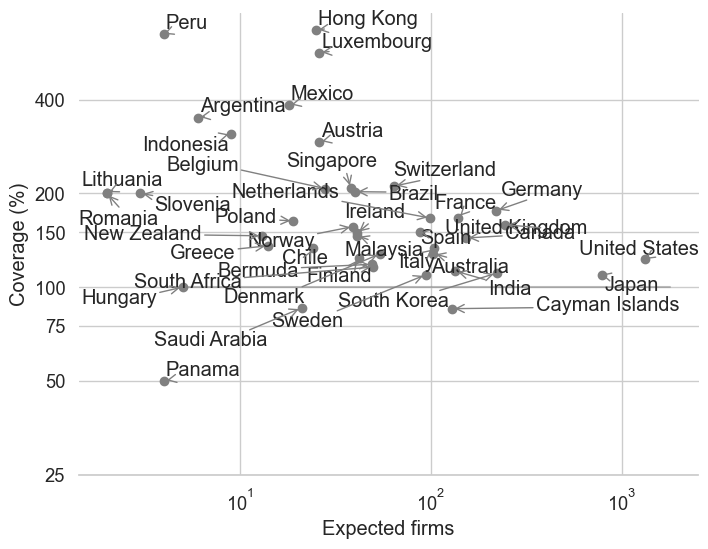

In [8]:
#CBCR number of companies
total_cov = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
total_cov = total_cov.loc[total_cov["Year"]==YEAR_CBCR]
total_cov = total_cov.loc[total_cov["Grouping"]=="All Sub-Groups"]
total_cov = total_cov.loc[total_cov["Variable"]=="Number of CbCRs"]
total_cov = total_cov.loc[total_cov["JUR"]==total_cov["COU"]]
total_cov = total_cov.groupby(["COU"]).max()["Value"]

## Compare quality with Orbis (companies with >750M of turnover, including estimates, and keeping companies with foreign subsidiaries)
cs = pd.read_excel(ORBIS_FILE,na_values=["n.a."],keep_default_na=False)
cs = cs.dropna(subset=["GUO - BvD ID number"])
cs = cs.loc[(cs["Country ISO code"]==cs["GUO - BvD ID number"].str[:2])|(cs["GUO - BvD ID number"].str[:2]=="WW")]
cs["max_turnover"] = cs.groupby(["GUO - BvD ID number"])["Operating revenue (Turnover)\nth USD Last avail. yr"].transform(max)
cs = cs.loc[cs["Operating revenue (Turnover)\nth USD Last avail. yr"]==cs["max_turnover"]]
print(cs["GUO - BvD ID number"].value_counts().head()) #makek sure no repeated, in case of equal turnovers

cs = cs.drop_duplicates(subset=["GUO - BvD ID number"])
cs.loc[(cs["Country ISO code"]!=cs["GUO - BvD ID number"].str[:2])&(cs["GUO - BvD ID number"].str[:2]!="WW"),"Country ISO code"] = cs.loc[(cs["Country ISO code"]!=cs["GUO - BvD ID number"].str[:2])&(cs["GUO - BvD ID number"].str[:2]!="WW"),"GUO - BvD ID number"].str[:2]
print(cs["GUO - BvD ID number"].value_counts().head()) #makek sure no repeated, in case of equal turnovers

cs = cs.groupby("Country ISO code").agg({"GUO - BvD ID number": len,"Operating revenue (Turnover)\nth USD Last avail. yr":np.sum,"Number of employees\nLast avail. yr":np.sum}).reset_index()
cs.columns = ["country","Number companies expected","Turnover expected","Emp expected"]
cs["Turnover expected"] *= 1000
cs["country"] = cs["country"].map(get_iso3)
cs = cs.dropna(subset=["country"])

#This array is used in 99.cluster_photoshop
potential_countries = cs.loc[cs["Number companies expected"]>=3,"country"].values

cs = pd.concat([cs.set_index("country"),total_cov],axis=1)
cs["Coverage"] = np.log2(cs["Value"]/cs["Number companies expected"])


cs_plot = cs.dropna()
plt.figure(figsize=(8,6))
plt.plot(cs_plot["Number companies expected"],cs_plot["Coverage"],"o",color="gray")

texts = []
for c,x,y in zip(cs_plot.index,cs_plot["Number companies expected"],cs_plot["Coverage"]):
    texts.append(plt.text(x,y,iso3_to_name(c)))


plt.plot([4,1800],[0,0],alpha=0.5,color="gray")             
plt.xscale("log")

adjust_text(texts,cs_plot["Number companies expected"].values, cs_plot["Coverage"].values, 
            arrowprops=dict(arrowstyle='->', color='gray'))
bins = np.array([0.25,0.5,0.75,1,1.5,2,4])
coverage = np.log2(bins)
plt.yticks(coverage,np.array(100*bins,dtype=int))
plt.xlabel("Expected firms")
plt.ylabel("Coverage (%)")
sns.despine(bottom=False,left=True)


expected_companies = cs["Number companies expected"]
expected_companies = expected_companies.to_dict()
expected_companies["DNK"]

In [9]:
cs_plot["Ratio"] = cs_plot["Number companies expected"]/cs_plot["Value"]
x = cs_plot[["Number companies expected","Value","Ratio"]].sort_values(by="Ratio", ascending=False)
x.index = x.index.map(iso3_to_name)
x["Number companies expected"] = x["Number companies expected"].astype(int)
x["Value"] = x["Value"].astype(int)
x["Ratio"] = x["Ratio"].round(2)
x

,Number companies expected,Value,Ratio
Panama,4,2,2.00
Cayman Islands,129,110,1.17
Saudi Arabia,21,18,1.17
Hungary,5,5,1.00
Sweden,94,103,0.91
Japan,785,861,0.91
South Korea,221,245,0.90
India,134,151,0.89
South Africa,50,58,0.86
Bermuda,49,58,0.84


In [10]:
potential_countries

array(['ARE', 'ARG', 'AUT', 'AUS', 'BEL', 'BHR', 'BMU', 'BRA', 'CAN',
       'CHE', 'CHL', 'CHN', 'COL', 'CYP', 'CZE', 'DEU', 'DNK', 'EGY',
       'ESP', 'FIN', 'FRA', 'GBR', 'GRC', 'HKG', 'HUN', 'IDN', 'IRL',
       'ISR', 'IND', 'IRN', 'ITA', 'JPN', 'KOR', 'KWT', 'CYM', 'KAZ',
       'LUX', 'MAR', 'MEX', 'MYS', 'NGA', 'NLD', 'NOR', 'NZL', 'PAN',
       'PER', 'PHL', 'POL', 'PRT', 'QAT', 'RUS', 'SAU', 'SWE', 'SGP',
       'SVN', 'THA', 'TUR', 'TWN', 'USA', 'VGB', 'VNM', 'ZAF'],
      dtype=object)

In [11]:
df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
# df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Year"]==YEAR_CBCR]
df = df.loc[df["Variable"].isin(fin_needed)]
df = pd.pivot_table(df,index=["COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9

In [12]:
df = pd.read_csv(CBCR_FILE)
df = df.loc[df["Year"]==2017]
df1 = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
a = df1[["COU","Partner Jurisdiction"]].drop_duplicates().reset_index(drop=True)["COU"].value_counts()

df1 = df.loc[df["Grouping"]=="All Sub-Groups"]
b = df1[["COU","Partner Jurisdiction"]].drop_duplicates().reset_index(drop=True)["COU"].value_counts()

pd.concat([b,a],axis=1).transpose().fillna(0).astype(int)

,JPN,IND,DEU,USA,ZAF,CHN,CHE,ESP,DNK,ITA,BMU,MEX,LUX,FRA,AUS,IDN,BRA,MYS,SGP,BEL,PER,ARG,CAN,LVA,CHL,IMN,SVN,ROU,GBR,SWE,GRC,NOR,AUT,POL,FIN,KOR,IRL,NLD
COU,200,164,161,147,139,125,122,120,115,110,101,97,92,90,82,43,43,36,29,21,20,19,16,14,10,7,7,7,7,7,6,6,6,5,2,2,2,2
COU,185,135,158,99,115,92,121,80,115,81,69,61,91,40,57,31,31,27,38,21,12,15,16,0,10,7,6,7,6,7,6,6,5,0,2,2,2,2


In [13]:
#Make sure the cleaning in 2016  (multiplying everything by 2 in china) was mostly okay
df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
# df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = df.loc[df["Variable"].isin(fin_needed+['Number of CbCRs'])]
df = pd.pivot_table(df,index=["Year","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
# df.dropna(subset=["Adjusted Profit (Loss) before Income Tax"])[["JUR","Profit (Loss) before Income Tax", "Adjusted Profit (Loss) before Income Tax"]].set_index("JUR")/1E9
df.loc[(df["JUR"]=="COD")]


Variable,Year,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
853,2016,ZAF,COD,Democratic Republic of the Congo,NaN,4.379733e+06,5.813607e+06,4.0,4.0,177.0,7.0,55954533.0,4.693023e+07,1.019855e+08
1287,2017,CHN,COD,Democratic Republic of the Congo,NaN,1.869742e+07,1.155755e+07,7.0,7.0,4057.0,19.0,68889224.0,6.037538e+08,1.684346e+08
2043,2017,JPN,COD,Democratic Republic of the Congo,NaN,1.052030e+06,5.057420e+05,1.0,1.0,234.0,2.0,3795278.0,2.943714e+07,6.015086e+07
2573,2017,ZAF,COD,Democratic Republic of the Congo,NaN,3.601608e+06,1.790003e+06,2.0,2.0,149.0,2.0,10299477.0,3.474348e+07,7.490633e+07
2909,2018,CHE,COD,Democratic Republic of the Congo,NaN,NaN,NaN,2.0,2.0,NaN,7.0,NaN,NaN,NaN
3205,2018,DEU,COD,Democratic Republic of the Congo,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4401,2018,ROU,COD,Democratic Republic of the Congo,NaN,6.314050e+05,5.354520e+05,1.0,1.0,66.0,1.0,6330187.0,6.029443e+07,4.829127e+07


## 1.2 Read and clean CBCR
- Data limitations: https://www.oecd.org/tax/tax-policy/anonymised-and-aggregated-cbcr-statistics-disclaimer.pdf
- Report: https://www.oecd.org/tax/tax-policy/corporate-tax-statistics-database.htm


- Data on the United States --> Cleaned in the paper with Zucman
    - US domestic: 55%
    - US foreign: 7% (https://gabriel-zucman.eu/files/GBJZ2021.pdf)

- Other countries: correct using notes when possible:
    - Ireland: https://www.oecd.org/tax/tax-policy/ireland-cbcr-country-specific-analysis.pdf
        --> No issues found
    - Italy: https://www.oecd.org/tax/tax-policy/italy-cbcr-country-specific-analysis.pdf
        -->  The average value of the share of dividends is instead equal to 38.2%, thus implying that dividends are concentrated in few firms.  
    - Netherlands: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
        --> 5794 out of 36802 = 15.74%
    - United Kingdom: https://www.oecd.org/tax/tax-policy/united-kingdom-cbcr-country-specific-analysis.pdf
        --> UK reported profit.: The total value of dividends extracted for groups we believe had included intragroup dividends received was approximately £55 billion. (78.169865 out of 152.918884 = 51.1%) 	)
    - Sweden: https://www.oecd.org/tax/tax-policy/sweden-cbcr-country-specific-analysis.pdf
        --> Dividends share 51.95%


Correct for dividends, but not for participation results (de-mergers, takeovers and disposal typically involve tax avoidance strategies in tax havens.) 


Cleaning strategy based on the analysis below:
- Profit and coordination centers:
    - Domestic: Analysis done for those countries (except Belgium and LUX)
        - Belgium: 50% (same as uk/swe)
        - LUX: Nothing (tax rates are usually around there)
    - Foreign : 
        -Remove 10% (a bit more than what we find in the US for that year (9% = 42 double counting/454 tax havens))
- USA:
    - Domestic: 
        - Remove 35%
    - Foreign: 
        - No correction


- Other countries:
    - Domestic:
        - If domestic etr << foreign etr (10 points): Correct as in ita (35%)
    - Foreign: 
        - No correction

- Groups:
    - Domestic:
        - N/A
    - Foreign:
        - Remove 5% (10% from tax havens, with 50% of profits in tax havens)


/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will defaul

Text(0, 0.5, 'ETR (Foreign MNCs)')

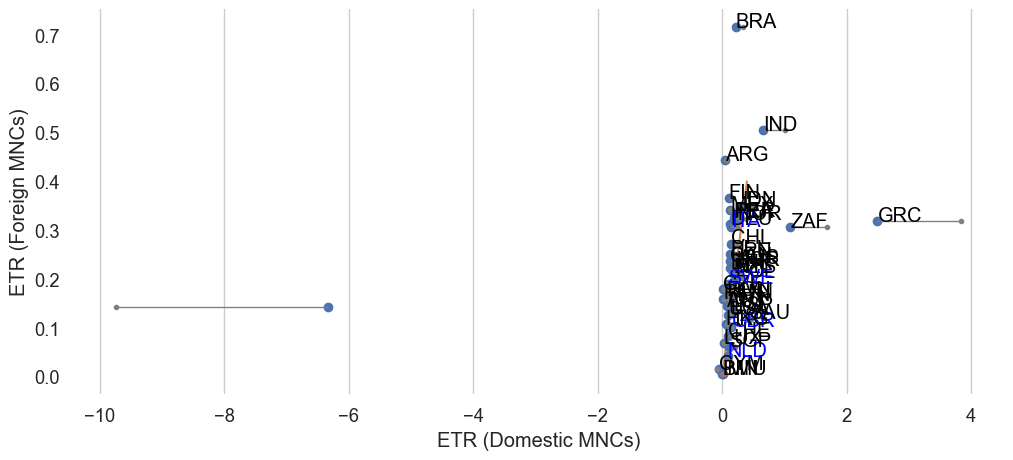

In [14]:
#Check out cleaning. USe all groups to get a most comparable picture
df_etrs = main_etrs(year=YEAR_CBCR,file=CBCR_FILE,g="All Sub-Groups")
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs

plt.figure(figsize=(12,5))
for i,row in df_etrs.iterrows():
    if row["ETR_domestic"]>-0.2:
        if i in ["NLD","GBR","ITA","SWE"]:
            color = "blue"
        else:
            color = "black"
        plt.annotate(i,(row["ETR_domestic"],row["ETR_foreign"]),color=color)
plt.plot(df_etrs["ETR_domestic"],df_etrs["ETR_foreign"],"o")


def plot_c(cs,color="tomato"):
    c,fraction = cs
    plt.plot(df_etrs.loc[c,"ETR_domestic"]*(1+fraction/(1-fraction)),df_etrs.loc[c,"ETR_foreign"],".",color=color)
    plt.plot([df_etrs.loc[c,"ETR_domestic"]*(1+fraction/(1-fraction)),df_etrs.loc[c,"ETR_domestic"]],[df_etrs.loc[c,"ETR_foreign"],df_etrs.loc[c,"ETR_foreign"]],lw=1,color=color)

d_reduction = dict()
for c in df_etrs.dropna(subset=["ETR_domestic"]).index:
    d = dict([("SWE",0.52),("ITA",0.38),("USA",0.35)]) #2017
#     d = dict([("SWE",0.52),("ITA",0.38)]) #2016
    
    if c in ["BEL","SGP","IMN","BMU"]: 
        plot_c((c,0.5),color="red")
        frac = 0.5
    elif c in ["SVN","MEX"]: #2017
#     elif c in ["SVN","USA","CHN","MEX"]: #2016
        frac = 0
    elif c in d:
        plot_c((c,d[c]),color="cornflowerblue")
        frac = d[c]
    elif c in ("GBR","NLD"): #2017
#     elif c in []: #2016
        frac = 0 #They report their figure of adjusted profits
    elif c == "LUX": #negative profits
        frac = 0
    else:
        frac = 0.35
    d_reduction[c] = frac
    plot_c((c,frac),color="gray")
        
plt.plot([0,0.4],[0,0.4],zorder=0)
plt.grid(axis="y")
sns.despine(left=True,bottom=True)
plt.xlabel("ETR (Domestic MNCs)")
plt.ylabel("ETR (Foreign MNCs)")
# plt.plot([0,0.4],[0.05,0.45])

In [15]:
# Manually adjust countries without domestic ETRs for "sub-groups with positive profits". Use all sub-groups in this case
df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Year"]==YEAR_CBCR]
missing_c = (set(df.loc[(df["COU"]==df["JUR"])&(df["Grouping"]=="All Sub-Groups"),"COU"]) -
         set(df.loc[(df["COU"]==df["JUR"])&(df["Grouping"]=="Sub-Groups with positive profits"),"COU"]))
df = df.loc[df["Grouping"]=="All Sub-Groups"]
df = pd.pivot_table(df,index=["Year","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
#Calculate etr
display(main_etrs(YEAR_CBCR,df.loc[(df["JUR"].isin(missing_c))]))

#Manually adjust
d_reduction["AUT"] = 0.35 #2017 only, much lower etr domestic
d_reduction["LVA"] = 0 #2017 only, higher for etr domestic
d_reduction["POL"] = 0.35 #2016 and 2017much lower etr domestic

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will defaul

,ETR_foreign,ETR_domestic,ETR_total
JUR,,,
CZE,0.179995,0.015819,0.120534
HUN,0.157314,0.081806,0.131900
LVA,0.131024,0.143152,0.138714
PAN,0.160156,0.021509,0.072373
POL,0.203071,0.207982,0.204921


In [16]:

#Clean data CBCR
df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df = df.loc[df["Variable"].isin(fin_needed)]
# df = df.loc[df["Grouping"]=="Sub-Groups with positive profits"]
df = df.loc[df["Year"]==YEAR_CBCR]
df = pd.pivot_table(df,index=["Grouping","COU","JUR","Partner Jurisdiction"],values="Value",columns="Variable").reset_index()
df = df.dropna(subset=["Income Tax Paid (on Cash Basis)"])


#Countries with analysis
if "Adjusted Profit (Loss) before Income Tax" in list(df.columns):
    print("Cleaning countries with corrected data: NLD and GBR")
    display(df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"])])
    df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),"Profit (Loss) before Income Tax"] = df.loc[~np.isnan(df["Adjusted Profit (Loss) before Income Tax"]),"Adjusted Profit (Loss) before Income Tax"]

print("Cleaning countries with analysis: ITA, SWE, BEL, USA")
df["Reduction"] = df["COU"].map(d_reduction).fillna(0)

filter_ = (df["COU"]==df["JUR"])&(df["Profit (Loss) before Income Tax"]>0)

d1 = df.loc[filter_].groupby(["COU","Grouping"])["Profit (Loss) before Income Tax"].sum()/1E9
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-df.loc[filter_,"Reduction"])
d2 = df.loc[filter_].groupby(["COU","Grouping"])["Profit (Loss) before Income Tax"].sum()/1E9
d = pd.concat([d1,d2],axis=1).reset_index()
display(d.loc[d["Grouping"]=="All Sub-Groups"])

print("Cleaning foreign activities in tax havens")
filter_ = (df["COU"]!=df["JUR"]) & (df["JUR"].isin(ofcs))&(df["Profit (Loss) before Income Tax"]>0)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-0.1)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)

print("Cleaning foreign activities in groups")
filter_ = (df["COU"]!=df["JUR"]) & (df["JUR"].isin(groups | {"FJT"}))&(df["Profit (Loss) before Income Tax"]>0)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)
df.loc[filter_,"Profit (Loss) before Income Tax"] = df.loc[filter_,"Profit (Loss) before Income Tax"]*(1-0.05)
print(df.loc[filter_,"Profit (Loss) before Income Tax"].sum()/1E9)


df.to_excel(cbcr_output)

Cleaning countries with corrected data: NLD and GBR


Variable,Grouping,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues
1126,All Sub-Groups,GBR,GBR,United Kingdom,1.750596e+10,1.171499e+10,1.007553e+10,387.0,387.0,3164742.0,21717.0,6.680190e+10,8.524017e+11,9.894753e+11
1878,All Sub-Groups,NLD,NLD,Netherlands,2.177767e+10,4.934474e+09,4.238728e+09,165.0,165.0,582272.0,6647.0,4.613006e+10,1.246143e+11,3.088054e+11
4022,Sub-Groups with negative profits,NLD,NLD,Netherlands,-4.440012e+09,-1.781823e+08,3.130935e+08,48.0,48.0,76442.0,1132.0,-4.714633e+09,2.379649e+10,2.786139e+10
5215,Sub-Groups with positive profits,GBR,GBR,United Kingdom,8.027598e+10,1.003663e+10,8.049864e+09,259.0,259.0,2458346.0,14579.0,1.295719e+11,6.833192e+11,7.611233e+11
5852,Sub-Groups with positive profits,NLD,NLD,Netherlands,2.621768e+10,5.112656e+09,3.925635e+09,117.0,117.0,505830.0,5515.0,5.084469e+10,1.008178e+11,2.809440e+11


Cleaning countries with analysis: ITA, SWE, BEL, USA


,COU,Grouping,Profit (Loss) before Income Tax,Profit (Loss) before Income Tax
0,ARG,All Sub-Groups,17.394704,11.306557
2,AUS,All Sub-Groups,89.433549,58.131807
4,AUT,All Sub-Groups,17.260176,11.219115
6,BEL,All Sub-Groups,18.109300,9.054650
8,BMU,All Sub-Groups,5.202382,2.601191
10,BRA,All Sub-Groups,57.436841,37.333946
12,CAN,All Sub-Groups,147.456309,95.846601
14,CHE,All Sub-Groups,57.563629,37.416359
16,CHL,All Sub-Groups,13.374077,8.693150
19,CZE,All Sub-Groups,6.794214,4.416239


Cleaning foreign activities in tax havens
1942.7005628621928
1748.4305065759738
Cleaning foreign activities in groups
7644.687948908701
7262.453551463266


In [17]:
# df = pd.read_csv(CBCR_FILE,usecols=["COU","JUR","Year","Partner Jurisdiction","Grouping","Variable","Value"])
df.loc[(df["COU"]=="CHN")].sort_values(by="Profit (Loss) before Income Tax").tail(10)

Variable,Grouping,COU,JUR,Partner Jurisdiction,Adjusted Profit (Loss) before Income Tax,Income Tax Accrued - Current Year,Income Tax Paid (on Cash Basis),Number of CbCR Sub Groups,Number of CbCRs,Number of Employees,Number of Entities,Profit (Loss) before Income Tax,Tangible Assets other than Cash and Cash Equivalents,Unrelated Party Revenues,Reduction


In [18]:
df_etrs = main_etrs(year=YEAR_CBCR,file=df.loc[df["Grouping"]=="Sub-Groups with positive profits"])
df_etrs["cit"] = df_etrs.index.map(iso3_to_cit)
df_etrs.loc[df_etrs["ETR_foreign"]>0.6,"ETR_foreign"] = df_etrs.loc[df_etrs["ETR_foreign"]>0.6,"cit"]
df_etrs.loc[df_etrs["ETR_total"]>0.6,"ETR_total"] = df_etrs.loc[df_etrs["ETR_total"]>0.6,"cit"]
df_etrs.to_excel(etr_output)
df_etrs.loc["AUT"]

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will defaul

ETR_foreign     0.116317
ETR_domestic    0.090339
ETR_total       0.105574
cit             0.250000
Name: AUT, dtype: float64

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  d = df.loc[df["Income Tax Paid (on Cash Basis)"]>=0].groupby("JUR").sum()
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/2176849684.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will defaul

Text(0.5, 1.0, '(B) Corrected for double counting')

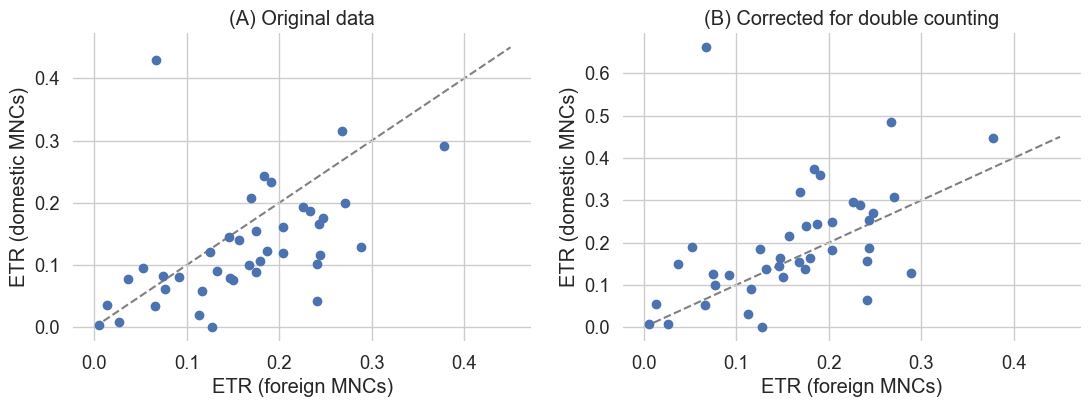

In [19]:
df_etrs2 = main_etrs(year=YEAR_CBCR,file=CBCR_FILE,g="Sub-Groups with positive profits")
d = pd.concat([df_etrs, df_etrs2],axis=1)
d.columns = ["f1","d1","t1","cit","f2","d2","t2"]

def plot_etr_robustness(d,v2):
    plt.plot(d["f1"],d[v2],"o")
    plt.plot([0,0.45],[0,0.45],"--",color="gray",zorder=0)
    plt.xlabel("ETR (foreign MNCs)")
    plt.ylabel("ETR (domestic MNCs)")
    sns.despine(bottom=True,left=True)
    
plt.figure(figsize=(13,4))
plt.subplot(121)
plot_etr_robustness(d,"d2")
plt.title("(A) Original data")

plt.subplot(122)
plot_etr_robustness(d,"d1")
plt.title("(B) Corrected for double counting")

In [20]:
#Fix code for kosovo
df["COU"] = df["COU"].replace({"XKV": "XKX"})
df["JUR"] = df["JUR"].replace({"XKV": "XKX"})

In [21]:
# df_fin.loc[df_fin["iso3_o"]=="USA"].sort_values(by="pi",ascending=False)

## 2. Create other variables to train the model

## 2.1. Financial information

In [22]:
#Financial variables
df_fin = df.loc[df["Grouping"]=="All Sub-Groups",["COU","JUR","Number of Employees","Profit (Loss) before Income Tax","Income Tax Paid (on Cash Basis)","Unrelated Party Revenues","Tangible Assets other than Cash and Cash Equivalents"]]
df_fin.columns = ["iso3_o","iso3_d","emp","pi","txc","revt","t_at"]
df_fin["iso3_d"] = df_fin["iso3_d"].replace("ANT","CUW")


In [23]:
## Countries to include
countries_include = set([_ for _ in df_fin["iso3_d"].unique() if not isinstance(get_iso3(_),float)]) - {"IOT","BVT"}# - {"BVT","GUM","ASM","VIR"} #tiny ocuntry with almost no profits, not in the distance dataset

FJT not matched to any file
OAF not matched to any file
OAM not matched to any file
OAS not matched to any file
OTE not matched to any file
STA not matched to any file
AFRIC not matched to any file
AMER not matched to any file
ASIAT not matched to any file
EUROP not matched to any file
GRPS not matched to any file


/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/1938015452.py:2: DeprecationWarning: This method is going to be deprecated use name_to_iso3 and iso3_to_iso2 instead.
  countries_include = set([_ for _ in df_fin["iso3_d"].unique() if not isinstance(get_iso3(_),float)]) - {"IOT","BVT"}# - {"BVT","GUM","ASM","VIR"} #tiny ocuntry with almost no profits, not in the distance dataset


## 2.2 Basic info and impute missing wages

DOM 607.9799657013828 295.0916666666667 0.7228558877390823
HKG 3694.574548496141 1766.34 0.7379557961474342
IDN 310.2788081734313 143.37666666666667 0.771996074573145
MEX 803.7543627469869 335.57 0.873463125063284
PRT 1808.6968679081065 987.238 0.6054507573637677
QAT 5435.377848128284 2945.0171428571425 0.6128144013407031
SEN 114.80706276037894 0.32999999999999996 5.85191562881761
                            OLS Regression Results                            
Dep. Variable:     np.log(month_wage)   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     753.1
Date:                Tue, 22 Nov 2022   Prob (F-statistic):           1.20e-68
Time:                        14:58:42   Log-Likelihood:                -29.822
No. Observations:                 123   AIC:                             65.64
Df Residuals:                     120   BIC:                   

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/1028474256.py:15: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  ohter_info[i] = ohter_info.groupby(['iso3'], sort=False)[i].apply(lambda x: x.ffill(limit=3).bfill(limit=3))
/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/1028474256.py:15: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior a

,iso3,year,IP_payments_wb,IP_receipts_wb,FDI_inflows_WDI_wb,External_debt_stocks_wb,Govt_exp_gdp_wb,Total_reserves_wb,Number_of_new_businesses_registered_wb,Imports_wb,Exports_wb,GDP_pc_wb,GDP_deflator_wb,Govt_exp_educ_gdp_wb,Physicians_per_1000_wb,Nurses_per_1000_wb,Health_exp_gdp_wb,GreenfieldFDI_outward,GreenfieldFDI_inward,resource_revenue,resource_taxes,total_taxes_revenue,cit_revenue,who_gvt_health_expenditure,month_wage,GDP_int,POP_int,FSI2020_Rank,FSI2020_Share,FSI2020_Score,CTHI21_Rank,CTHI21_Share,CTHI21_Score,region,region_tjn,EU28,OECD,G20,UKt,OECD_OCT,Physicians,Nurses,gdppc,resource_revenue_gdp,cit
0,ABW,2016.5,1.282184e+07,945630.208909,9.984615e+07,NaN,NaN,7.616557e+08,NaN,2.257647e+09,2.196802e+09,28297.965809,150.340587,1.805556e+08,NaN,NaN,NaN,6.666667e+04,1.681667e+07,NaN,0.0,6.598631e+08,NaN,NaN,2178.216533,3.020530e+09,105053.50,112.0,0.002251,73.275,56.0,0.002126,70.134565,Americas,Caribbean/American isl.,0.0,0.0,0.0,0.0,1.0,NaN,NaN,28752.298556,NaN,0.25
1,AFG,2016.5,3.100611e+06,60295.319685,7.834258e+07,2.629006e+09,8.030519e+11,7.014350e+09,2942.666667,NaN,NaN,546.033215,104.628082,7.257109e+08,0.282957,0.17215,1.959768e+09,1.076667e+07,6.741667e+07,NaN,NaN,1.538945e+09,2.307434e+08,9.969294e+07,86.206298,1.941160e+10,35734394.75,NaN,NaN,NaN,NaN,NaN,NaN,Asia,Asia,0.0,0.0,0.0,0.0,0.0,10111.30224,10111.30224,543.218985,NaN,0.20


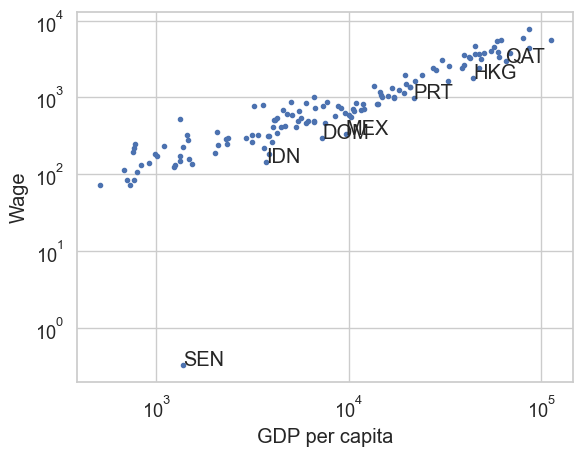

In [24]:

## Read region
region = pd.read_csv(UNILATERAL_CROSS,skiprows=1,sep="\t",usecols=["iso3","region_tjn","region","UKt","OECD","OECD_OCT","EU28","G20",
                                                               "FSI2020_Rank","FSI2020_Share","FSI2020_Score","CTHI21_Rank","CTHI21_Share","CTHI21_Score"])

##Other info
usecols = ["iso3","year","GDP_int","POP_int","Physicians_per_1000_wb","Nurses_per_1000_wb","GreenfieldFDI_inward","GreenfieldFDI_outward",
           "resource_revenue","resource_taxes","total_taxes_revenue","cit_revenue","Health_exp_gdp_wb","Govt_exp_educ_gdp_wb",
          "FDI_inflows_WDI_wb","External_debt_stocks_wb",'IP_payments_wb','IP_receipts_wb','who_gvt_health_expenditure',"month_wage",
           'Total_reserves_wb','Number_of_new_businesses_registered_wb','Imports_wb','Exports_wb','GDP_pc_wb','GDP_deflator_wb','Govt_exp_gdp_wb']

ohter_info = pd.read_csv(UNILATERAL_PANEL,skiprows=1,sep="\t",usecols=usecols)

#Fill forward to get old data (in case of missing)
for i in ["GDP_int","POP_int","Physicians_per_1000_wb","Nurses_per_1000_wb"]:
    ohter_info[i] = ohter_info.groupby(['iso3'], sort=False)[i].apply(lambda x: x.ffill(limit=3).bfill(limit=3))

#Keep mean >2010
ohter_info = ohter_info.loc[ohter_info["year"]>last_year_mean].groupby("iso3").mean().reset_index()

#Merge with region
ohter_info = pd.merge(ohter_info,region,how="outer")

#Raw numbers
ohter_info["Physicians"] = ohter_info["Physicians_per_1000_wb"]*ohter_info["POP_int"]/1000
ohter_info["Nurses"] = ohter_info["Physicians_per_1000_wb"]*ohter_info["POP_int"]/1000

#GDP per capita
ohter_info["gdppc"] = ohter_info["GDP_int"]/ohter_info["POP_int"]

#Convert to USD
for i in ['who_gvt_health_expenditure',"resource_revenue","resource_taxes","total_taxes_revenue","cit_revenue","Health_exp_gdp_wb","Govt_exp_educ_gdp_wb","Govt_exp_gdp_wb"]:
    ohter_info[i] = ohter_info[i]*ohter_info["GDP_int"]
    
ohter_info["resource_revenue_gdp"] = ohter_info["resource_revenue"]/ohter_info["GDP_int"]

ohter_info["Govt_exp_educ_gdp_wb"] /= 100
ohter_info["Health_exp_gdp_wb"] /= 100

remove = []
for i,x,y in zip(ohter_info["iso3"],ohter_info["GDP_int"]/ohter_info["POP_int"],ohter_info["month_wage"]):
    if (np.log(x/12/y)>np.log2(1.5)) or (np.log(x/12/y)<-2):
        print(i,x/12,y,np.abs(np.log(x/12/y)))
        plt.annotate(i,(x,y))
        remove.append(i)
plt.plot(ohter_info["GDP_int"]/ohter_info["POP_int"],ohter_info["month_wage"],".")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("GDP per capita")
plt.ylabel("Wage")

#Delete the problematic ones
ohter_info.loc[ohter_info["iso3"].isin(remove),"month_wage"] = np.nan


mod = smf.ols(formula='np.log(month_wage) ~ np.log(GDP_int) + np.log(POP_int)', data=ohter_info)

res = mod.fit()

print(res.summary())

ohter_info["pred_month_wage"] = np.exp(res.predict(ohter_info))
ohter_info.loc[np.isnan(ohter_info["month_wage"]),"month_wage"] = ohter_info.loc[np.isnan(ohter_info["month_wage"]),"pred_month_wage"]

del ohter_info["pred_month_wage"]
#Fix the departing ones
ohter_info.loc[ohter_info["iso3"]=="USA","month_wage"] =  4056 #https://www.bls.gov/news.release/pdf/wkyeng.pdf
ohter_info.loc[ohter_info["iso3"]=="AUS","month_wage"] =  5661 #https://www.abs.gov.au/statistics/labour/earnings-and-work-hours/average-weekly-earnings-australia/latest-release

#ADD CIT
ohter_info["cit"] = ohter_info["iso3"].map(iso3_to_cit)
ohter_info = ohter_info.drop_duplicates()

ohter_info.to_csv(info_expenditures_output, sep="\t", index=None)
 


ohter_info.head(2)

In [25]:
iso3_to_gdp = ohter_info.set_index("iso3")["GDP_int"].dropna().to_dict()
pickle.dump(iso3_to_gdp,open(iso3_to_gdp_output,"wb+"))


In [26]:
a = pd.read_csv(UNILATERAL_PANEL,skiprows=1,sep="\t",nrows=1).columns
[_ for _ in a if "govt_ex" in _.lower()]

['Govt_exp_gdp_wb', 'Govt_exp_educ_gdp_wb', 'Govt_exp_educ_govtexp_wb']

In [27]:
#Other info
df_region = ohter_info.drop(columns=["year"])
df_region = df_region.rename(columns={"iso3":"iso3_d"})
df_region = df_region.drop_duplicates(subset=["iso3_d"]).dropna(subset=["iso3_d"])
iso3_to_region = df_region.set_index("iso3_d")["region_tjn"]

In [28]:
iso3_to_wages = ohter_info.set_index("iso3")["month_wage"].dropna().to_dict()
pickle.dump(iso3_to_wages,open(iso3_to_wages_output,"wb+"))


In [29]:
ohter_info.set_index("iso3")["month_wage"]

iso3
ABW    2178.216533
AFG      86.206298
AGO     395.539215
AIA    1681.598930
ALA    3599.174655
          ...     
UMI            NaN
PAL            NaN
ROM            NaN
TMP            NaN
ZAR            NaN
Name: month_wage, Length: 274, dtype: float64

## 2.3 Gravity dataset

In [30]:
def add_eq(df_dist,list_c,eq):
    """copies the data of another country"""
    for c in list_c:
        x = df_dist.loc[df_dist["iso3_o"]==eq]
        x["iso3_o"] = c
        df_dist = pd.concat([df_dist,x])
        x = df_dist.loc[df_dist["iso3_d"]==eq]
        x["iso3_d"] = c
        df_dist = pd.concat([df_dist,x])
    return df_dist



In [31]:
# Read gravity variables
df_dist = pd.read_stata(GRAV_FILE)
df_dist = df_dist.loc[df_dist["year"]>last_year_mean].groupby(["iso3_o","iso3_d"]).mean().reset_index()

df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ROM","ROU")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ROM","ROU")
df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("TLS","TMP")
df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("TLS","TMP")
# df_dist["iso3_o"] = df_dist["iso3_o"].str.replace("ANT","CUW")
# df_dist["iso3_d"] = df_dist["iso3_d"].str.replace("ANT","CUW")
df_dist = df_dist.loc[(df_dist["iso3_o"]!="ANT")&(df_dist["iso3_d"]!="ANT")]

df_dist = add_eq(df_dist,["JEY","IMN","GGY"],"GBR")
# df_dist = add_eq(df_dist,["SRB","MNE"],"ALB")
# df_dist = add_eq(df_dist,["MCO"],"AND")
# df_dist = add_eq(df_dist,["SSD"],"SDN")
# df_dist = add_eq(df_dist,["COD"],"COG")
df_dist = add_eq(df_dist,["TLS"],"COG")


/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/4238962354.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_dist = df_dist.loc[df_dist["year"]>last_year_mean].groupby(["iso3_o","iso3_d"]).mean().reset_index()


In [32]:
df_dist["iso3_d"].value_counts().head(5) #make sure there are no duplicates

ABW    251
PHL    251
NGA    251
NIC    251
NIU    251
Name: iso3_d, dtype: int64

In [33]:
set(df_fin["iso3_d"]) - set(df_dist["iso3_o"])

{'AFRIC',
 'AMER',
 'ASIAT',
 'EUROP',
 'FJT',
 'GRPS',
 'MAF',
 'OAF',
 'OAM',
 'OAS',
 'OTE',
 'STA',
 'VIR',
 'XKX'}

In [34]:
for i in set(df_fin["iso3_d"]) - set(df_dist["iso3_o"]):
    try:
        iso3_to_name(i)
    except:
        print(i)

STA
OAS
FJT
AMER
GRPS
AFRIC
EUROP
ASIAT
OTE
OAF
OAM


## 2.4 Variables from Linkedin

In [35]:
# Linkedin variables
df_link = pd.read_csv(LINK_FILE,sep="\t",index_col=0,na_values=[""],keep_default_na=False)
df_link["iso3_d"] = df_link["index"].map(get_iso3)
df_link = df_link.drop(columns=["index","country","ln_pi"])
df_link = df_link.drop_duplicates(subset=["iso3_d"])

## 2.5 Bilateral info

In [36]:
df_bil = pd.read_csv(BILATERAL_CROSS,skiprows=1,sep="\t")
df_bil = df_bil.groupby(["r_iso3","p_iso3"]).mean().reset_index()
df_bil = df_bil.loc[:,["r_iso3","p_iso3", 'Export', 'Import','dClaims','dLiabilities','PortI_inward','PortI_outward', 'FDI_inward', 'FDI_outward']]
for v in ['Export', 'Import','dClaims','dLiabilities','PortI_inward','PortI_outward', 'FDI_inward', 'FDI_outward']:
    df_bil["ln_"+v] = np.log(df_bil[v]+1)
    del df_bil[v]
    
df_bil = df_bil.rename(columns={"r_iso3":"iso3_o", "p_iso3": "iso3_d"})

df_bil

,iso3_o,iso3_d,ln_Export,ln_Import,ln_dClaims,ln_dLiabilities,ln_PortI_inward,ln_PortI_outward,ln_FDI_inward,ln_FDI_outward
0,ABW,AFG,13.558630,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,AGO,16.031576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,AIA,NaN,NaN,NaN,NaN,NaN,NaN,16.234725,NaN
3,ABW,ALB,5.680173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,AND,NaN,8.065894,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
50596,ZWE,WSM,9.679281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50597,ZWE,XKX,8.497195,4.615121,NaN,NaN,NaN,NaN,NaN,NaN
50598,ZWE,YEM,12.695013,8.216298,NaN,NaN,NaN,NaN,NaN,NaN
50599,ZWE,ZAF,21.414037,21.765608,18.801398,17.95201,17.530718,NaN,20.997196,19.539148


## 2.5 Combine datasets into a bilateral dataset

In [37]:
iso3_to_etr = df_etrs["ETR_total"].to_dict()

In [38]:
## Dataset to impute (financials and weird stuff) (destination files)
#Keep the non-bilateral columns (note the drop_duplicates)
x = df_dist.loc[:,[_ for _ in df_dist.columns if  (_[-2:]=="_d") and (_ not in ["heg_d","gsp_d_d","gsp_o_d","eu_d","tradeflow_comtrade_d","tradeflow_imf_d"])]].drop_duplicates()
print(x.shape) #should be around 257 countries

df_destination = pd.merge(x,df_region,how="outer") #TODO G&B have here cit column
df_destination = pd.merge(df_destination,df_link.drop(columns=["cit","ln_gdp"]),how="left",on=["iso3_d"],suffixes=["","_d"])
df_destination["n_companies_orb"] = df_destination["iso3_d"].map(expected_companies).fillna(0) #TODO cit column is already here

#Add efective tax rate
df_destination["etr_real_d"] = df_destination["iso3_d"].map(iso3_to_etr)
df_destination["ln_etr_real_d"] = np.log(0.001+df_destination["etr_real_d"])
df_destination = df_destination.dropna(subset=["GDP_int"])

remove_cols_dest = df_destination.columns

#Take the logarithm for many variiables
columns = np.array(df_destination.columns)[df_destination.dtypes!=object]
for var in columns: #TODO for  here there is the cit column
    if (var == "english") or (var == "etr") or ("ln" in var) or ("comrelig" in var) or ("comleg" in var) or ("cit" == var): #TODO check if last clause if correct - Introduced to avoid error running the notebook
        continue
    if len(df_destination.loc[:,var].unique()) < 5:
        continue
    m = np.min(df_destination.loc[:,var].dropna())
    if m>0:
        m = 0
#     print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
    if ("GDP" in var) or (var == "distw") or ((np.mean(df_destination.loc[:,var]-m) > 2.*np.median(df_destination.loc[:,var].dropna()-m))):# or (var in ["Total FSI","cthi"]):
        print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))
        df_destination["ln_"+var] = np.log(1+df_destination.loc[:,var]-m)
        del df_destination[var]
        
        
        

(251, 17)
pop_d 0 5.077000442528059
gdp_d 0 14.09332830386494
gdpcap_d 0 2.560259
gdp_ppp_d 0 8.535453812573799
pop_pwt_d 0 4.5476217
gdp_ppp_pwt_d 0 8.760627
entry_cost_d 0.0 2.2800646773861057
IP_payments_wb 0.0 102.51609877874105
IP_receipts_wb -1450000.0 639.0185957868126
FDI_inflows_WDI_wb -16511270891.149502 2.1285552710952307
External_debt_stocks_wb 0 6.675609951217662
Govt_exp_gdp_wb 0 29.53566974701323
Total_reserves_wb 0 13.112930278394959
Number_of_new_businesses_registered_wb 0 4.112735124481498
Imports_wb 0 16.63951858693969
Exports_wb 0 18.35708696419348
GDP_pc_wb 0 2.657379982584792
GDP_deflator_wb 0 1.9406377284207565
Govt_exp_educ_gdp_wb 0 34.20411590376001
Health_exp_gdp_wb 0 43.43038331696661
GreenfieldFDI_outward 0.0 65.23476847816588
GreenfieldFDI_inward 0.0 10.707845801180115
resource_revenue 0.0 509.5642368828771
resource_taxes -155287474.1095227 7.039656662227149
total_taxes_revenue 0 18.011236353282005
cit_revenue 0.0 15.14869126515853
who_gvt_health_expenditur

/var/folders/vj/vnmnz5qj13l5kmxflkz59knc0000gn/T/ipykernel_5043/3477767149.py:29: RuntimeWarning: divide by zero encountered in double_scalars
  print(var,m,np.mean(df_destination.loc[:,var]-m)/(np.median(df_destination.loc[:,var].dropna()-m)))


In [39]:
df_destination = df_destination.loc[(df_destination["iso3_d"]!="WLD")] 

columns = np.array(df_destination.columns)[df_destination.dtypes!=object]
# df_destination = impute(df_destination,columns)


df_destination.columns = [_+"_d" if _[-2:]!="_d" else _ for _ in df_destination.columns]

for var in ["ln_resource_revenue_d", "ln_resource_revenue_gdp_d","ln_total_taxes_revenue_d","ln_cit_revenue_d"]:
    df_destination.loc[df_destination[var]<0,var] = 0


df_destination2 = df_destination.copy()
df_destination2.columns = [_[:-1]+"o" if _[-2:]=="_d" else _ for _ in df_destination.columns] 

# #Add dummies
# df_destination = pd.concat([df_destination,pd.get_dummies(df_destination["iso3_d"])],axis=1)

print(df_destination.shape)

countries_include - set(df_destination["iso3_d"])

(239, 89)


{'MAF'}

In [40]:
#Create a full dataset
pairs = list(product(countries_include,repeat=2))
pairs = pd.DataFrame(pairs,columns=["iso3_o","iso3_d"])

pairs = pd.merge(pairs, df_fin,how="left",validate="1:1")
pairs = pd.merge(pairs,df_destination,how="left",on=["iso3_d"],validate="m:1")
pairs = pd.merge(pairs,df_destination2,how="left",suffixes=["_d","_o"],on=["iso3_o"],validate="m:1") 

df_dist2 = df_dist.loc[:,["iso3_o","iso3_d"]+[_ for _ in df_dist if (_ not in df_destination.columns) and (_ not in df_destination2.columns) and ("ln"+_ not in df_destination.columns) and ("ln"+_ not in df_destination2.columns) and (_ not in remove_cols_dest)]]
pairs = pd.merge(pairs,df_dist2,how="left",on=["iso3_o","iso3_d"],validate="1:1") 
pairs = pd.merge(pairs,df_bil,how="left",on=["iso3_o","iso3_d"],validate="1:1")

# pairs = pairs.drop(columns=["conflict","indepdate","sever","sib_conflict","pta_bb","fta_bb","fta_hmr"])
pairs = pairs.drop(columns=["sib_conflict"])


print(pairs.dropna(subset=["pi"]).shape)

(2355, 231)


In [41]:
pairs["ln_etr_real_o"] = np.log(0.01+pairs["etr_real_o"])
pairs["ln_etr_real_d"] = np.log(0.01+pairs["etr_real_d"])

In [42]:
pairs["ln_cit_o"] = np.log(0.01+pairs["cit_o"])
pairs["ln_cit_d"] = np.log(0.01+pairs["cit_d"])

In [43]:
set(["gdp_o","pop_o","gdpcap_o","entry_cost_o","area_o","eu_o","eu_d","year","region_d","region_o"])-set(pairs.columns)

{'area_o'}

In [44]:
pairs = pairs.drop(columns=["gdp_o","pop_o","gdpcap_o","entry_cost_o","eu_o","eu_d","year","region_d","region_o"])

In [45]:
for i in pairs.columns:
    if len(pairs)-pairs[i].count() > 0 :
        print(i,len(pairs)-pairs[i].count())

emp 43016
pi 43014
txc 43014
revt 43015
t_at 43016
iso3num_d 639
country_exists_d 639
gmt_offset_2020_d 639
gdpcap_ppp_d 5112
gatt_d 639
wto_d 639
entry_proc_d 6390
entry_time_d 6390
entry_tp_d 6390
Physicians_per_1000_wb_d 7029
Nurses_per_1000_wb_d 6816
FSI2020_Rank_d 17679
FSI2020_Share_d 17679
FSI2020_Score_d 17679
CTHI21_Rank_d 30885
CTHI21_Score_d 30885
region_tjn_d 213
EU28_d 213
OECD_d 213
G20_d 213
UKt_d 213
OECD_OCT_d 426
cit_d 1278
ratings_d 1065
english_d 1065
Total FSI_d 1065
ln_accountant_d 1065
ln_all_tax_d 1065
ln_banker_d 1065
ln_ceo_d 1065
ln_cfo_d 1065
ln_coo_d 1065
ln_cxo_d 1065
ln_engineer_d 1065
ln_other_corporate_d 1065
ln_physician_d 1065
ln_tax_compliance_audit_d 1065
ln_transfer_pricing_d 1065
ln_wealth_d 1065
ln_audience_d 1065
ln_consumption_d 1065
ln_gfcf_d 1065
ln_population_d 1065
ln_uhnwi_d 1065
ln_BIS_d 1065
ln_finance_d 1065
governance_d 1065
ln_gdppc_d 213
tax_complex_d 1065
cthi_d 1065
etr_real_d 3621
ln_etr_real_d 3621
ln_pop_d 1704
ln_gdp_d 2982
ln_

In [46]:
# #fill missing (very few values coming from the distancefile only)
# columns = np.array(pairs.columns)[pairs.dtypes!=object]
# columns = [_ for _ in columns if _ not in df_fin.columns]

# # pairs = impute(pairs,columns)

In [47]:
for var in ["emp","revt","pi","t_at","distw"]:
    pairs["ln_"+var] = np.log(1+pairs.loc[:,var]-m)
    del pairs[var]

/Users/danielcoll/opt/miniconda3/envs/sotj_profit_shifting_estimates/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/danielcoll/opt/miniconda3/envs/sotj_profit_shifting_estimates/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/danielcoll/opt/miniconda3/envs/sotj_profit_shifting_estimates/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/danielcoll/opt/miniconda3/envs/sotj_profit_shifting_estimates/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [48]:
pairs.to_csv(df_pairs_output,sep="\t",index=None)
df_fin.to_csv(df_fin_output,sep="\t",index=None)

In [49]:
df_fin.head()

,iso3_o,iso3_d,emp,pi,txc,revt,t_at
0,ARG,ARG,159354.0,1.130656e+10,7.262580e+08,6.026053e+10,9.545845e+10
1,ARG,AUS,1.0,6.242739e+06,0.000000e+00,6.582965e+06,4.296447e+05
2,ARG,BOL,154.0,1.628879e+06,1.106431e+06,1.180915e+08,7.660177e+07
3,ARG,BRA,5868.0,1.586243e+08,2.017510e+07,9.337754e+08,8.925710e+08
4,ARG,CHL,2221.0,-1.002867e+09,-1.644266e+05,1.943392e+09,2.179786e+09


In [50]:
pairs.head()

,iso3_o,iso3_d,txc,iso3num_d,country_exists_d,gmt_offset_2020_d,gdpcap_ppp_d,gatt_d,wto_d,entry_proc_d,entry_time_d,entry_tp_d,Physicians_per_1000_wb_d,Nurses_per_1000_wb_d,FSI2020_Rank_d,FSI2020_Share_d,FSI2020_Score_d,CTHI21_Rank_d,CTHI21_Score_d,region_tjn_d,EU28_d,OECD_d,G20_d,UKt_d,OECD_OCT_d,cit_d,ratings_d,english_d,Total FSI_d,ln_accountant_d,ln_all_tax_d,ln_banker_d,ln_ceo_d,ln_cfo_d,ln_coo_d,ln_cxo_d,ln_engineer_d,ln_other_corporate_d,ln_physician_d,ln_tax_compliance_audit_d,ln_transfer_pricing_d,ln_wealth_d,ln_audience_d,ln_consumption_d,ln_gfcf_d,ln_population_d,ln_uhnwi_d,ln_BIS_d,ln_finance_d,governance_d,...,ln_Nurses_o,ln_resource_revenue_gdp_o,ln_n_companies_orb_o,contig,dist,distcap,distwces,dist_source,comlang_off,comlang_ethno,comcol,comrelig,col45,comleg_pretrans,comleg_posttrans,transition_legalchange,heg_o,heg_d,col_dep_ever,col_dep,col_dep_end_year,col_dep_end_conflict,sibling_ever,sibling,sever_year,gdp_ppp_o,pop_pwt_o,gdp_ppp_pwt_o,rta,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d,ln_Export,ln_Import,ln_dClaims,ln_dLiabilities,ln_PortI_inward,ln_PortI_outward,ln_FDI_inward,ln_FDI_outward,ln_cit_o,ln_cit_d,ln_emp,ln_revt,ln_pi,ln_t_at,ln_distw
0,BMU,BMU,59663056.0,60.0,1.0,-4.0,75.773250,0.0,0.0,NaN,NaN,NaN,NaN,NaN,40.0,0.008489,72.725,3.0,100.000000,Caribbean/American isl.,0.0,0.0,0.0,1.0,1.0,0.000,78.0,1.000000e+00,73.050000,6.236370,4.262680,4.110874,6.673298,5.081404,4.709530,5.602119,5.888878,3.713572,4.615121,3.044522,0.000000e+00,3.433987,10.738590,21.654178,20.783585,11.075288,0.668787,11.505377,7.882692,2.505517,...,NaN,NaN,3.912023,0.0,2.738000,2.738000,19.977,1.0,0.0,0.0,0.0,0.107496,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,4.856591e+06,62.034199,3837904.75,0.0,NaN,NaN,NaN,NaN,NaN,NaN,14.272756,14.272756,NaN,NaN,NaN,NaN,NaN,NaN,-4.60517,-4.605170,8.230844,23.656490,21.679235,24.332075,3.211045
1,BMU,RWA,NaN,646.0,1.0,2.0,1.925000,1.0,1.0,6.000000,5.142857,11.142858,0.120950,1.061438,99.0,0.002951,63.000,NaN,NaN,Africa,0.0,0.0,0.0,0.0,0.0,0.300,31.0,0.000000e+00,71.812635,7.923348,5.141664,5.442418,7.372118,4.795791,5.081404,5.141664,8.137688,3.044522,6.634633,4.262680,0.000000e+00,2.397895,12.144734,22.684619,21.702217,16.273464,0.701684,3.784190,8.354910,0.045481,...,NaN,NaN,3.912023,0.0,10589.686523,10589.686523,10569.499,1.0,1.0,1.0,0.0,0.134736,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,NaN,4.856591e+06,62.034199,3837904.75,0.0,NaN,10.946000,NaN,NaN,5.250000,5.565000,NaN,6.526495,NaN,NaN,NaN,15.998560,NaN,NaN,-4.60517,-1.171183,NaN,NaN,NaN,NaN,9.265833
2,BMU,GHA,0.0,288.0,1.0,0.0,4.637571,1.0,1.0,8.000000,13.857143,21.857143,0.147050,2.770250,117.0,0.001600,51.700,61.0,51.686886,Africa,0.0,0.0,0.0,0.0,0.0,0.250,23.0,1.000000e+00,61.750000,9.364005,6.608001,8.959440,10.454236,6.364751,6.938284,7.848153,10.186069,4.262680,8.177797,5.252273,2.397895e+00,4.510860,14.076413,24.480458,22.354336,17.165023,0.975136,9.143452,10.681688,0.061634,...,NaN,NaN,3.912023,0.0,7300.520020,7300.520020,7200.836,1.0,1.0,1.0,1.0,0.104442,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,1957.0,4.856591e+06,62.034199,3837904.75,0.0,NaN,4.334667,NaN,NaN,4.088666,4.335000,NaN,8.768932,NaN,NaN,NaN,18.079245,NaN,18.785004,-4.60517,-1.347074,4.143135,13.045923,NaN,17.415017,8.882397
3,BMU,KWT,6425097.0,414.0,1.0,3.0,63.287000,1.0,1.0,9.857143,35.685714,45.542858,2.628433,7.087525,28.0,0.010842,70.575,NaN,NaN,Asia,0.0,0.0,0.0,0.0,0.0,0.150,90.0,1.665335e-16,65.633517,9.175852,5.303305,6.216606,8.068090,6.293419,5.638355,7.057037,10.449323,3.931826,7.848153,3.713572,2.220446e-16,3.931826,13.334407,24.484673,23.747053,15.185514,3.492676,10.255482,9.437556,-0.392214,...,NaN,NaN,3.912023,0.0,10168.592773,10168.592773,10164.481,1.0,0.0,1.0,1.0,0.004176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,1961.0,4.856591e+06,62.034199,3837904.75,0.0,NaN,37.816000,50.015333,50.015333,34.752251,36.836498,10.540514,6.040255,NaN,NaN,17.827915,17.634699,N

In [51]:
df_region_notna = df_region.dropna(subset=["iso3_d","region_tjn"])
OAF = AFRIC = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Africa","iso3_d"].dropna())
OAS = ASIAT = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Asia","iso3_d"].dropna())
OTE = EUROP = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Europe","iso3_d"].dropna())
OAM = LAC_sca = set(df_region_notna.loc[df_region_notna["region_tjn"].str.contains("America"),"iso3_d"].dropna())
GRPS = set(df_region_notna["iso3_d"].dropna())
LAC = set(df_region_notna.loc[df_region_notna["region_tjn"]=="Latin America and the Caribbean","iso3_d"].dropna())

d_groups2countries = {"OAF": OAF,
                     "AFRIC": AFRIC,
                     "OAS": OAS,
                     "ASIAT": ASIAT,
                     "OTE": OTE,
                     "EUROP": EUROP,
                     "OAM": OAM,
                     "LAC_sca": LAC_sca,
                     "GRPS": GRPS,
                     "LAC": LAC}

pickle.dump(d_groups2countries,open(d_groups2countries_output,"wb+"))
